Data Loaded Successfully

Cross Correlation Results

NDVI | Lag 0 | Correlation: 0.355
NDVI | Lag 1 | Correlation: 0.298
NDVI | Lag 2 | Correlation: 0.019
NDVI | Lag 3 | Correlation: -0.134
NDVI | Lag 4 | Correlation: -0.121
NDVI | Lag 5 | Correlation: -0.099
NDVI | Lag 6 | Correlation: -0.125
------------------------------
LST_Day | Lag 0 | Correlation: 0.162
LST_Day | Lag 1 | Correlation: 0.246
LST_Day | Lag 2 | Correlation: 0.238
LST_Day | Lag 3 | Correlation: 0.281
LST_Day | Lag 4 | Correlation: 0.290
LST_Day | Lag 5 | Correlation: 0.212
LST_Day | Lag 6 | Correlation: 0.006
------------------------------
Precip | Lag 0 | Correlation: 0.146
Precip | Lag 1 | Correlation: 0.290
Precip | Lag 2 | Correlation: 0.382
Precip | Lag 3 | Correlation: 0.262
Precip | Lag 4 | Correlation: 0.059
Precip | Lag 5 | Correlation: -0.111
Precip | Lag 6 | Correlation: -0.206
------------------------------

Best Lag Selection
{'NDVI': 0, 'LST_Day': 4, 'Precip': 2}

Lag variables created

Model Performanc

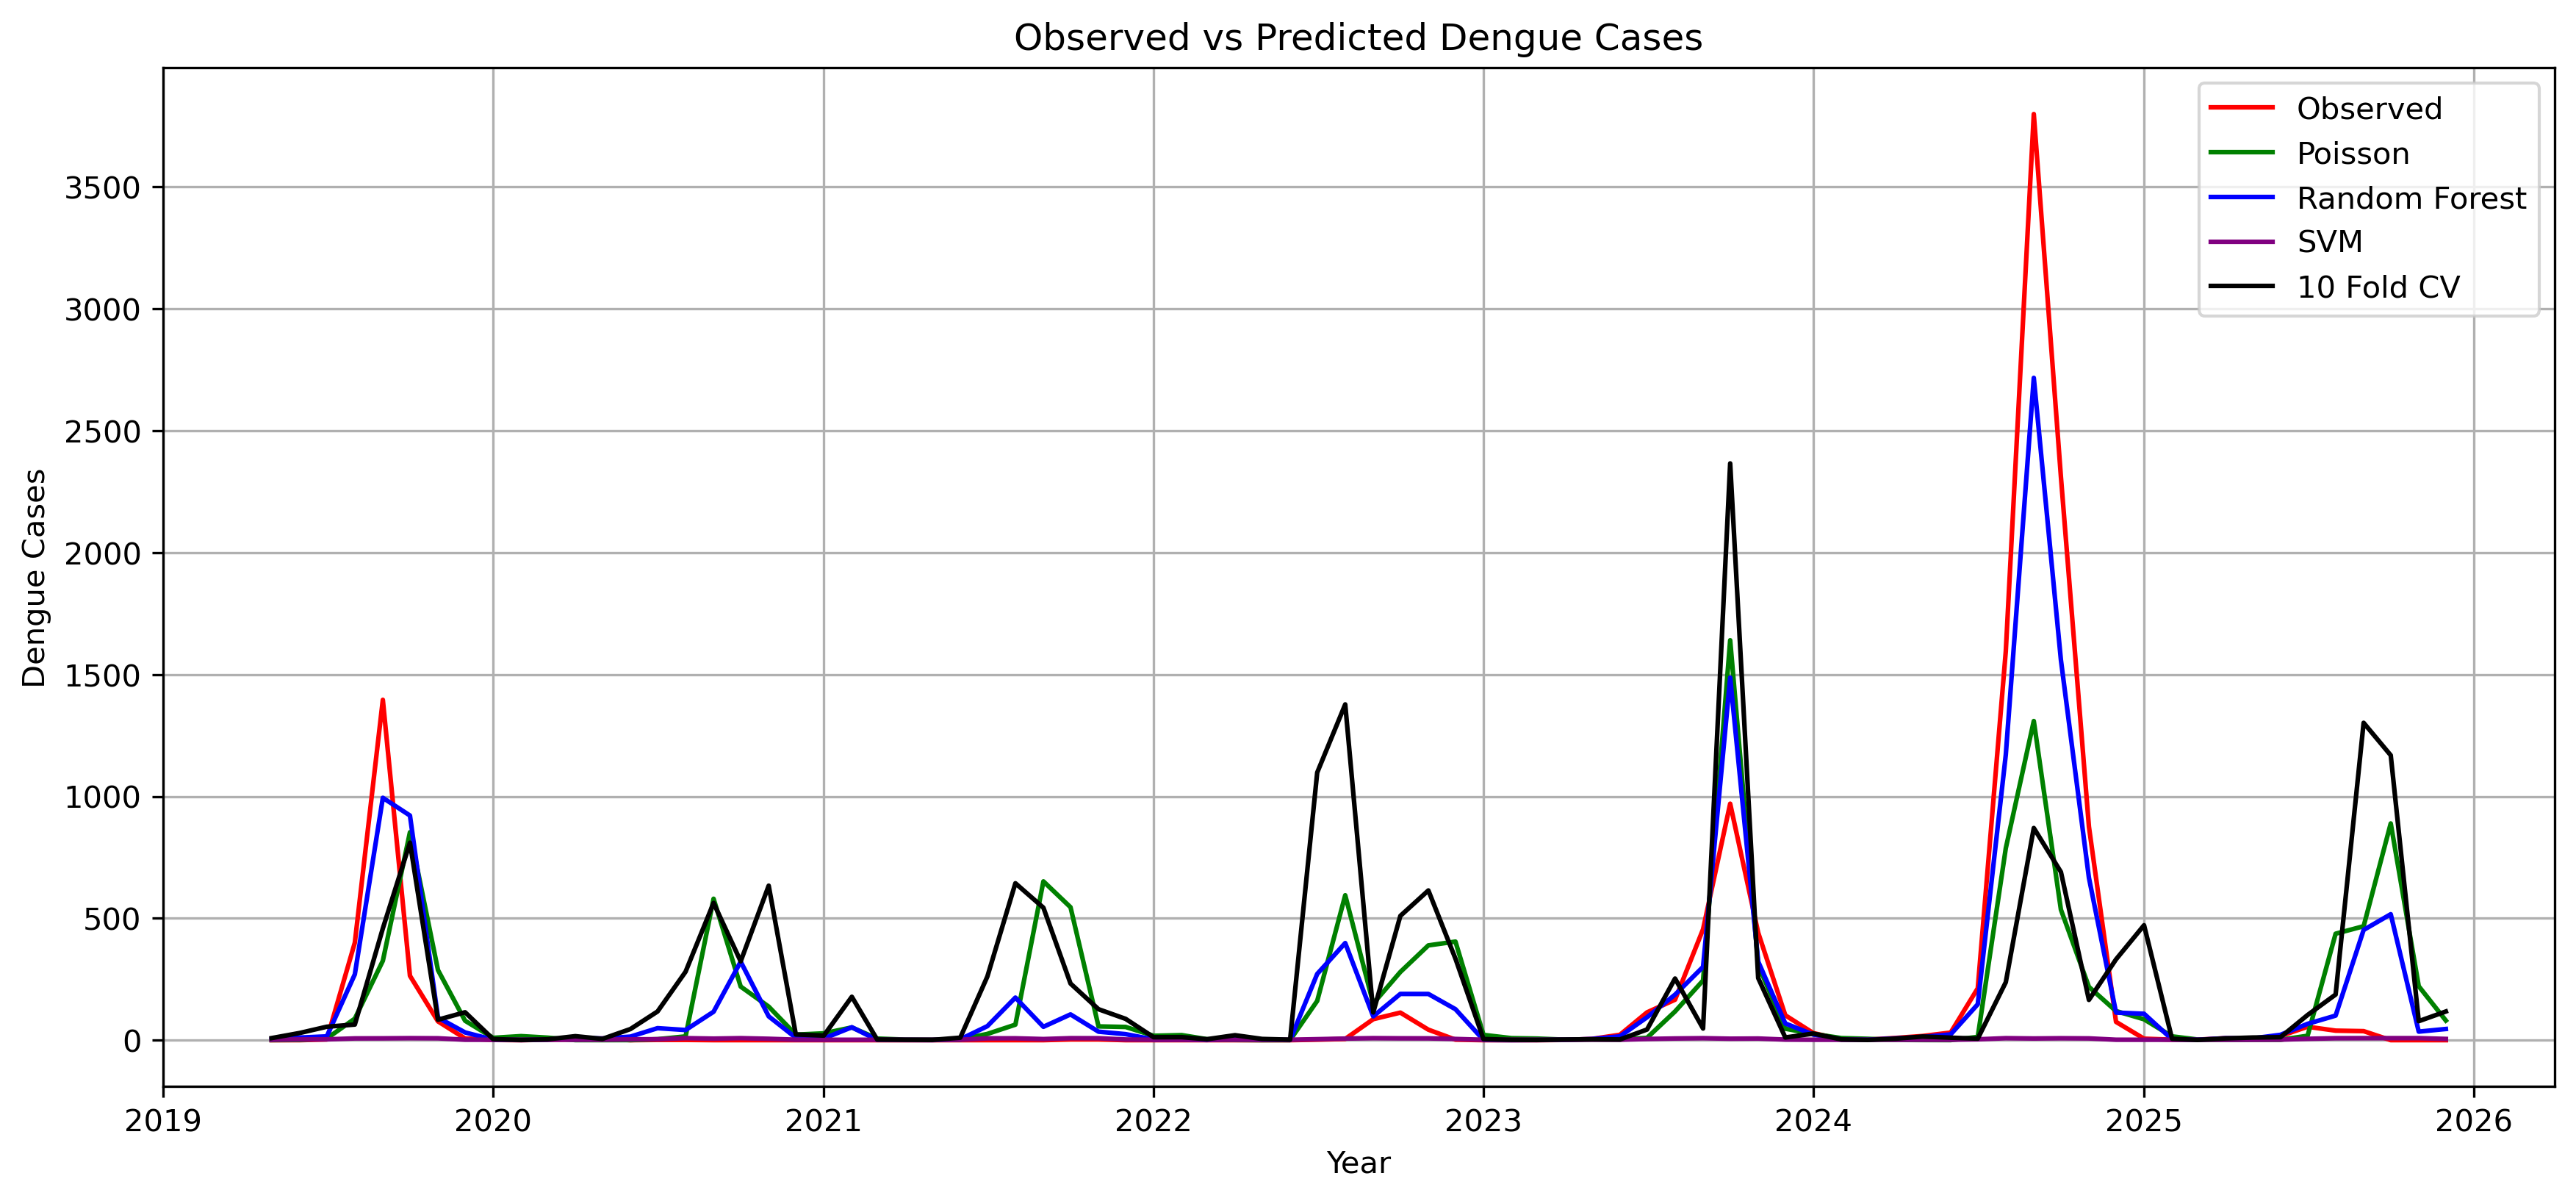


Results saved successfully


In [ ]:
# ==========================================
# Dengue Prediction Model Comparison
# Poisson vs Random Forest vs SVM
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.dates as mdates

# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv(r"C:\Users\dhrub\Desktop\Data\kaski_env_dengue_merged.csv")

df = df.sort_values(["year","month"]).reset_index(drop=True)

df["date"] = pd.to_datetime(df[["year","month"]].assign(day=1))

print("Data Loaded Successfully\n")

# ==========================================
# 2. CROSS CORRELATION ANALYSIS
# ==========================================

variables = ["NDVI","LST_Day","Precip"]
max_lag = 6

lag_results = {}

print("Cross Correlation Results\n")

for var in variables:

    correlations = []

    for lag in range(max_lag+1):

        corr = df["dengue_cases"].corr(df[var].shift(lag))
        correlations.append(corr)

        print(f"{var} | Lag {lag} | Correlation: {corr:.3f}")

    lag_results[var] = correlations

    print("------------------------------")

# ==========================================
# 3. FIND BEST LAG
# ==========================================

best_lags = {}

for var in variables:

    correlations = lag_results[var]

    best_lag = np.argmax(np.abs(correlations))

    best_lags[var] = best_lag

print("\nBest Lag Selection")
print(best_lags)

# ==========================================
# 4. CREATE LAG VARIABLES
# ==========================================

df["NDVI_lag"] = df["NDVI"].shift(best_lags["NDVI"])
df["LST_lag"] = df["LST_Day"].shift(best_lags["LST_Day"])
df["Precip_lag"] = df["Precip"].shift(best_lags["Precip"])

df = df.dropna().reset_index(drop=True)

print("\nLag variables created")

# ==========================================
# 5. PREPARE VARIABLES
# ==========================================

X = df[["NDVI_lag","LST_lag","Precip_lag"]]
y = df["dengue_cases"]

# ==========================================
# 6. POISSON REGRESSION
# ==========================================

X_sm = sm.add_constant(X)

poisson_model = sm.GLM(y, X_sm, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

df["poisson_pred"] = poisson_results.predict(X_sm)

# ==========================================
# 7. RANDOM FOREST MODEL
# ==========================================

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X, y)

df["rf_pred"] = rf.predict(X)

# ==========================================
# 8. SUPPORT VECTOR MACHINE
# ==========================================

svm = SVR(kernel="rbf")

svm.fit(X, y)

df["svm_pred"] = svm.predict(X)

# ==========================================
# 9. 10 FOLD CROSS VALIDATION (Random Forest)
# ==========================================

kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_predictions = np.zeros(len(df))

for train_index, test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train = y.iloc[train_index]

    model = RandomForestRegressor(n_estimators=500)

    model.fit(X_train, y_train)

    cv_predictions[test_index] = model.predict(X_test)

df["cv_pred"] = cv_predictions

# ==========================================
# 10. MODEL PERFORMANCE
# ==========================================

models = {
    "Poisson": df["poisson_pred"],
    "Random Forest": df["rf_pred"],
    "SVM": df["svm_pred"]
}

print("\nModel Performance\n")

for name, pred in models.items():

    mse = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, pred)

    print(name)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print("------------------")

# ==========================================
# 11. SELECT BEST MODEL
# ==========================================

best_model = max(models, key=lambda m: r2_score(y, models[m]))

print("\nBest Model:", best_model)

# ==========================================
# 12. PLOT RESULTS
# ==========================================

plt.figure(figsize=(14,6), dpi=300)

plt.plot(df["date"], df["dengue_cases"],
         color="red",
         label="Observed")

plt.plot(df["date"], df["poisson_pred"],
         color="green",
         label="Poisson")

plt.plot(df["date"], df["rf_pred"],
         color="blue",
         label="Random Forest")

plt.plot(df["date"], df["svm_pred"],
         color="purple",
         label="SVM")

plt.plot(df["date"], df["cv_pred"],
         color="black",
         label="10 Fold CV")

plt.xlabel("Year")
plt.ylabel("Dengue Cases")

plt.title("Observed vs Predicted Dengue Cases")

plt.legend()

plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.show()

# ==========================================
# 13. SAVE RESULTS
# ==========================================

df.to_csv("dengue_model_comparison_results.csv", index=False)

print("\nResults saved successfully")

In [2]:
# ==========================================
# 14. SAVE TRAINED MODELS
# ==========================================

import joblib

joblib.dump(poisson_results, "poisson_model.pkl")
joblib.dump(rf, "rf_model.pkl")
joblib.dump(svm, "svm_model.pkl")



['svm_model.pkl']